# ISO 20414:2020 — Test 6: Horizontal counter-flows

Two 10 m x 10 m rooms joined by a 10 m x 2 m corridor (ISO 20414:2020 Table 7). 100 occupants move from room 1 to room 2; the test is repeated with 0, 10, 50 and 100 counter-flow agents moving the other way. The time for room-1 agents to reach room 2 should increase with counter-flow.

In [1]:
from datetime import datetime

print(f"Executed on {datetime.now().astimezone().strftime('%d %B %Y, %H:%M %Z')}")

Executed on 08 July 2026, 09:37 CEST


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pedpy
from jupedsim_scenarios import load_scenario, run_scenario
from shapely.geometry import Point, Polygon

In [3]:
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "#f7f7f5",
        "axes.edgecolor": "#3a3a3a",
        "axes.labelcolor": "#1d1d1d",
        "axes.titleweight": "bold",
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 11,
        "figure.figsize": (8, 5),
    }
)

## Scenario check — geometry and trajectories

Before the numerical sweep, confirm the simulated scenario is the ISO Test 6 layout: two 10 m x 10 m rooms joined by a 10 m x 2 m corridor. Using the cf = 10 case, trajectories are coloured by group — the primary crowd flows room 1 -> room 2 (left to right) and the counter-flow agents move room 2 -> room 1 (right to left), meeting in the corridor.

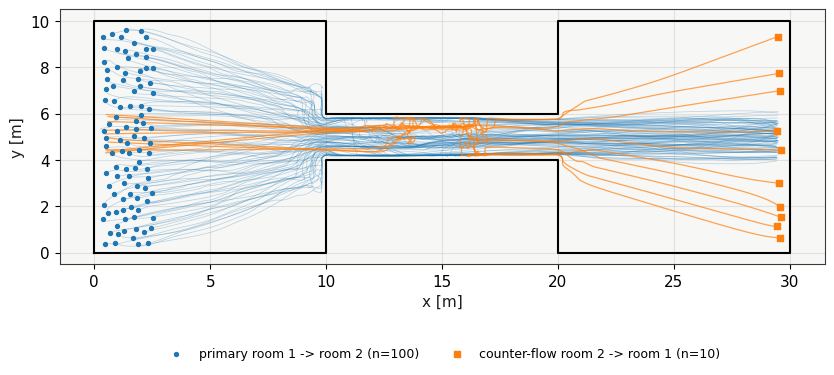

1

In [4]:
check = load_scenario(str(Path("scenario_files") / "Iso-06-counterflow-10.zip"))
check.max_simulation_time = 400
cr = run_scenario(check, seed=42)
cdf = cr.trajectory_dataframe().sort_values(["id", "frame"])
starts = cdf.groupby("id").first()
primary_ids = set(starts[starts.x < 5].index)  # start in room 1 -> room 2
counter_ids = set(starts[starts.x > 25].index)  # start in room 2 -> room 1

fig, ax = plt.subplots(figsize=(9, 3.6))
gx, gy = check.walkable_polygon.exterior.xy
ax.plot(gx, gy, "k-", lw=1.5)
for aid, sub in cdf.groupby("id"):
    if aid in primary_ids:
        ax.plot(sub.x, sub.y, color="tab:blue", alpha=0.3, lw=0.5)
    elif aid in counter_ids:
        ax.plot(sub.x, sub.y, color="tab:orange", alpha=0.7, lw=0.9)
ax.scatter(
    starts.loc[list(primary_ids)].x,
    starts.loc[list(primary_ids)].y,
    s=8,
    color="tab:blue",
    zorder=3,
    label=f"primary room 1 -> room 2 (n={len(primary_ids)})",
)
ax.scatter(
    starts.loc[list(counter_ids)].x,
    starts.loc[list(counter_ids)].y,
    s=20,
    marker="s",
    color="tab:orange",
    zorder=3,
    label=f"counter-flow room 2 -> room 1 (n={len(counter_ids)})",
)
ax.set_aspect("equal")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.28), ncol=2, fontsize=9, frameon=False)
plt.tight_layout()
plt.show()
cr.cleanup()

## Run each counter-flow branch

ISO Test 6 expects the crossing time to rise with counter-flow. For each counter-flow level we record the number of room-1 agents that reach room 2 (x >= 20 m) and their mean transit time. At high counter-flow CollisionFreeSpeedModel forms no lanes and the primary crowd deadlocks, so those agents never reach room 2.

In [5]:
CF_ZIPS = {
    0: "Iso-06-counterflow-0.zip",
    10: "Iso-06-counterflow-10.zip",
    50: "Iso-06-counterflow-50.zip",
    100: "Iso-06-counterflow-100.zip",
}
# One budget for every branch: the cf=0/10 crowds finish well inside 400 s
# (max reach ~70 s), and the cf>=50 crowds deadlock and never finish regardless.
MAX_TIME = 400
results = []
for cf, zip_name in CF_ZIPS.items():
    scenario = load_scenario(str(Path("scenario_files") / zip_name))
    scenario.max_simulation_time = MAX_TIME
    r = run_scenario(scenario, seed=42)
    df = r.trajectory_dataframe()
    primary = {
        int(aid)
        for aid, sub in df.sort_values(["id", "frame"]).groupby("id")
        if sub.iloc[0].x < 5.0
    }
    reached_room2 = []
    for aid in primary:
        sub = df[df.id == aid].sort_values("frame")
        r2 = sub[sub.x >= 20.0]
        if len(r2):
            reached_room2.append(r2.iloc[0].frame / r.frame_rate)
    results.append(
        {
            "counterflow": cf,
            "primary": len(primary),
            "reached_room2": len(reached_room2),
            "mean_reach_room2_s": float(np.mean(reached_room2)) if reached_room2 else float("nan"),
        }
    )
    r.cleanup()
transit = pd.DataFrame(results)
transit

,counterflow,primary,reached_room2,mean_reach_room2_s
0,0,100,100,30.193
1,10,100,100,44.867
2,50,100,1,52.400
3,100,100,0,NaN


## Plot agents reaching room 2, and crossing time where it is defined

The number of primary agents that reach room 2 collapses as counter-flow rises (100 -> 100 -> ~1 -> 0): the crowd deadlocks rather than slowing gracefully. Mean crossing time is a meaningful crowd statistic only where the whole crowd crossed (cf = 0 and 10, where it rises 30 s -> 45 s); at cf >= 50 almost nobody reaches room 2, so no crowd crossing time exists — which is exactly the failure.

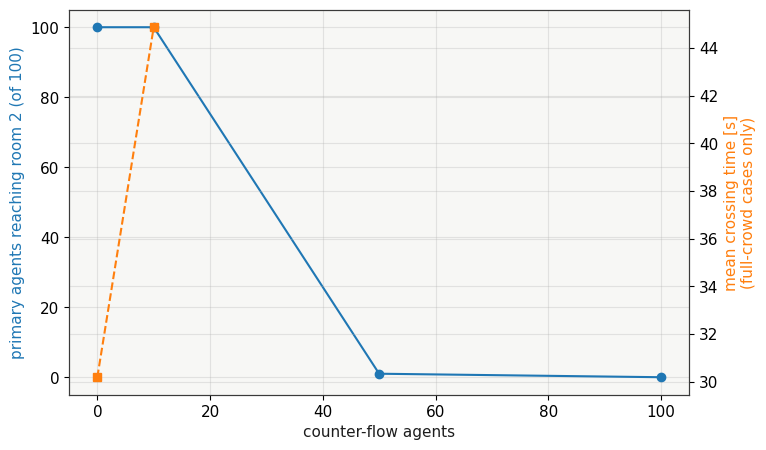

In [6]:
fig, ax1 = plt.subplots()
ax1.plot(transit["counterflow"], transit["reached_room2"], "o-", color="tab:blue")
ax1.set_xlabel("counter-flow agents")
ax1.set_ylabel("primary agents reaching room 2 (of 100)", color="tab:blue")
ax1.set_ylim(-5, 105)
# A "mean crossing time" is only meaningful where the whole crowd crossed;
# at cf >= 50 almost nobody reaches room 2, so those points are omitted rather
# than plotted as a mean over 0-1 agents.
full = transit[transit["reached_room2"] == transit["primary"]]
ax2 = ax1.twinx()
ax2.plot(full["counterflow"], full["mean_reach_room2_s"], "s--", color="tab:orange")
ax2.set_ylabel("mean crossing time [s]\n(full-crowd cases only)", color="tab:orange")
plt.show()

## Acceptance — FAIL

ISO 20414:2020 Test 6 expects the recorded crossing time to **increase** as the number of counter-flow agents rises, which requires the primary crowd to actually reach room 2. CollisionFreeSpeedModel forms no lanes: at >= 50 counter-flow agents the crowd effectively deadlocks and almost none of the primary agents reach room 2 (0–1 of 100 at cf >= 50 — a lone agent occasionally slips through, which is not lane formation), so no meaningful crossing time exists and the expected increase cannot be produced. The model therefore **fails** ISO Test 6.

ISO 20414:2020 directs that "if conditions of long-term blocking occur during the simulations, this should be documented" — this notebook is that record. Counter-flow with lane formation requires JuPedSim's AnticipationVelocityModel, not the CollisionFreeSpeedModel used here.

In [7]:
reached = transit["reached_room2"].to_numpy()
primary = transit["primary"].to_numpy()
stuck = transit.loc[reached < primary, "counterflow"].tolist()
print("reached room 2 (x>=20) / primary:", [f"{r}/{p}" for r, p in zip(reached, primary)])
print("mean time to room 2 [s]:", transit["mean_reach_room2_s"].to_numpy())
verdict = "FAIL" if stuck else "PASS"
print(f"\nRESULT: {verdict} - ISO 20414:2020 Test 6 (horizontal counter-flows)")
if stuck:
    print(f"Primary crowd deadlocks at counter-flow level(s) {stuck}: agents get stuck")
    print("and never reach room 2, so the ISO-expected crossing-time increase cannot")
    print("be produced. Documented CollisionFreeSpeedModel no-lane-formation limit.")

reached room 2 (x>=20) / primary: ['100/100', '100/100', '1/100', '0/100']
mean time to room 2 [s]: [30.193 44.867 52.4      nan]

RESULT: FAIL - ISO 20414:2020 Test 6 (horizontal counter-flows)
Primary crowd deadlocks at counter-flow level(s) [50, 100]: agents get stuck
and never reach room 2, so the ISO-expected crossing-time increase cannot
be produced. Documented CollisionFreeSpeedModel no-lane-formation limit.
